In [103]:
import simpy
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import random
import copy

# Proyecto de Simulación: Simulación de El Clásico ⚽
La idea es simular uno de los partidos de football más importantes de la historia del deporte, el clásico español FC Barcelona vs Real Madrid. A lo largo de los años ambos clubes se han enfrentado un total de 258 veces, dejando 105 victorias a favor del Real Madrid, 101 victorias a favor del FC Barcelona y 52 empates. 

Al simular este partido se tiene como meta (poniendonos en el papel de un entrenador real) anticipar estrategias para situaciones reales, identificar aquellos jugadores potenciales y que su aporte al equipo es más significativo este año que el anterior o quizás al revés, y finalmente, identificar los factores que puedend influir en la victoria del equipo.

# Variables 🔎 y Eventos ⭐
Las variables del sistema las veremos como entidades, debido a que muchos factores insiden en esta simulación, ejemplo: La media de los jugadores, sus resultados en la actual temporada, la cantidad de partidos jugados, etc. Para ello tendremos dos entidades fundamentales.

## Jugador
- **Número**: El número del jugador
- **Nombre**: El nombre del jugador
- **Posición**: La posición del jugador (Delantero, Centro Campista, Defensa, Portero)
- **Goles**: Goles en la actual temporada de Liga
- **Media Goles por Partido**: Media de goles por partido

## Equipo
- **Nombre**: El nombre del equipo
- **Jugadores**: Jugadores del equipo, divididos entre titulares y suplentes
- **Media**: Media total del equipo, combinación de la media de ataque, defensa y centro del campo
- **Moral**: Moral de los jugadores del equipo
- **Estilo**: El estilo de juego de los jugadores

Los eventos que se tendrán en cuenta son los siguientes:
- **Gol**: Gol en un instante de tiempo (medido en minuto)
- **Tarjeta Amarilla**: Tarjeta amarilla en un instante de tiempo (medido en minuto)
- **Tarjeta roja**: Tarjeta roja en un instante de tiempo (medido en minuto)
- **Sustitución**: Un equipo hace un cambio de jugadores

# Contantes

In [104]:
foward = "Forward"
midfielder = "Midfielder"
defender = "Defender"
goalkeeper = "Goalkeper"
styles = ["Ofensivo", "Contra Ataque", "Defensivos", "Agresivos"]

In [105]:
class player:
    def __init__(self, number: int, name: str, score: int, position: str, goals: int, mean_goals_per_play: float):
        self.number = number
        self.name = name
        self.score = score
        self.position = position
        self.goals = goals # Goles en Temporada
        self.yellow_cards = 0
        self.red_card = self.yellow_cards == 2
        self.mean_goals_per_play = mean_goals_per_play
        self.can_play = True

    def __str__(self):
        return f"{self.name}" + f"{self.score}"

In [106]:
class team:
    def __init__(self, id: int, name: str, titulars_players: list[player], banch_players: list[player], styles: list):
        self.id = id
        self.name = name
        self.players = titulars_players
        self.banch_players = banch_players
        self.attack = self.calculate_attack()
        self.defense = self.calculate_defense()
        self.middlefield = self.calculate_middle()
        self.overall = (self.attack + self.defense + self.middlefield) // 3
        self.styles = styles # Influye en la probabilidad de anotar un gol
        self.moral = 0 # Disminuye si expulsan a un jugador, Le sacan tarjeta amarilla, o si van perdiendo por mas de 2 goles
                       # Aumenta, si marcan goles, le expulsan un jugador contrario, o si van ganando
        self.cant_changes = 3
        

    def __str__(self):
        return f"{self.name}"
    
    def calculate_attack(self):
        atk = 0
        fowards = [player for player in self.players if not player.red_card and player.position == foward]
        for p in fowards:
            atk += p.score
        return atk // len(fowards)
    
    def calculate_middle(self):
        mid = 0
        midfielders = [player for player in self.players if not player.red_card and player.position == midfielder]
        for p in midfielders:
            mid += p.score
        return mid // len(midfielders)

    def calculate_defense(self):
        defense = 0
        defenders = [player for player in self.players if not player.red_card and (player.position == defender) or (player.position == goalkeeper)]
        for p in defenders:
            defense += p.score
        return defense // len(defenders)

# Implementación 👨🏻‍💻
Para llevar a cabo este proyecto, se investigó toda la información necesaria relacionada con eventos anteriores, se buscaron ejemplos de simulación de eventos discretos y sobre las diferentes distribuciones que podían tener las variables aleatorias. 

Se consultaron sitios especializados en estadísticas deportivas, para obtener valores como por ejemplo, la media de los jugadores o su promedio de goles por partidos. Al final del documento encontrará todos los enlaces y bibliografías utilizadas para el desarrollo de esta tarea. 

Para la implementación, se cuenta con la clase **SoccerSimulation**, en la cual se llevarán a cabo las simulaciones de los diferentes eventos. Tener en cuenta que la simulación se hace minuto a minuto llevando la variable time calculada correctamente. Dicha clase tiene varias listas para almacenar los distintos tipos de eventos, así como los minutos en los que ocurrieron, ejemplo **score_local_team** guarda en que minuto el equipo que juega de local anotó un gol. 

Más adelante se tocará más profundo el tema de la implementación y de los modelos probabilisticos que se utilizaron para la simulación y la ocurrencia de los eventos. 

In [107]:
import scipy.stats


class SoccerSimulation:
    def __init__(self, local_team: team, visitant_team: team):
        self.local_team = local_team
        self.visitant_team = visitant_team
        self.time = 0
        self.agregate_time = 0

        self.events_during_match = [] # Lista para guardar en que minuto ocurre uno de nuestros eventos definidos

        self.score_local_team = [] # Lista para guardar en que minutos el equipo local hace los goles
        self.score_visitant_team = [] # Lista para guardar en que minutos el equipo visitante los goles

        self.yellow_cards_local_team = [] # Lista para guardar en que minutos el equipo local recibe una tarjeta amarilla
        self.yellow_cards_visitant_team = [] # Lista para guardar en que minutos el equipo visitant

        self.red_cards_local_team = [] # Lista para guardar en que minutos el equipo local recibe una tarjeta roja
        self.red_cards_visitant_team = [] # Lista para guardar en que minutos el equipo visitante recibe una tarjeta roja

        self.sustitution_local_team = [] # Lista para guardar en que minutos el equipo local hace una sustitución
        self.sustitution_visitant_team = [] # Lista para guardar en que minutos el equipo visit

        self.possible_events = ["None", "Goal", "None", "Yellow Card", "None", "Red Card", "Sustitution"]

        self.yellow_card_prob = {
            defender: 0.45,
            midfielder: 0.35,
            foward: 0.25,
            goalkeeper: 0.15
        }

    def initializate(self):
        self.events_during_match = []
        self.score_local_team = []
        self.score_visitant_team = []
        self.yellow_cards_local_team = []
        self.yellow_cards_visitant_team = [] 
        self.red_cards_local_team = []
        self.red_cards_visitant_team = []
        self.sustitution_local_team = []
        self.sustitution_visitant_team = [] 
        self.time = 0
        
    def yellow_card(self, team: team, player: player):
        base_prob = self.yellow_card_prob[player.position]
        if team.moral < 0:
            base_prob *= 1.1
        minute_factor = 1.0 if self.time < 45 else 1.5
        yellow_prob = base_prob * minute_factor
        if random.random() < yellow_prob:
            if team == self.local_team:
                self.yellow_cards_local_team.append(self.time)
            else:
                self.yellow_cards_visitant_team.append(self.time)
            self.events_during_match.append(("Yellow Card", team.name))
            team.moral -= 1
            player.yellow_cards += 1
        else: self.events_during_match.append((f"Falta de {team.name}", "Sin Tarjeta"))

    def red_card(self, team: team, player: player):
        base_prob = self.yellow_card_prob[player.position]
        if team.moral < 0:
            base_prob *= 1.1
        minute_factor = 1.0 if self.time < 45 else 1.5
        red_prob = (base_prob * minute_factor * 0.05) / (0.01 if "Agresivo" in team.styles else 1)
        if random.random() < red_prob:
            if team == self.local_team:
                self.red_cards_local_team.append(self.time)
            else:
                self.red_cards_visitant_team.append(self.time)
            self.events_during_match.append(("Red Card", team.name))
            team.moral -= 2
            team.players.remove(player)
            self.agregate_time += 1
            self.events_during_match.append(("Red Card", team.name))
        else: self.events_during_match.append((f"Falta de {team.name}", "Sin Tarjeta"))

    def sustitution(self,team: team, player_onfield: player, player_on_banch: player):
        if team == self.local_team:
            self.sustitution_local_team.append(self.time)
        else:
            self.sustitution_visitant_team.append(self.time)
        team.players.remove(player_onfield)
        team.players.append(player_on_banch)
        self.events_during_match.append((f"Sustitution {player_onfield.name} por {player_on_banch}", team.name))
        player_onfield.can_play = False
        team.cant_changes -= 1

    def dynamic_function(self,opp_team: team, goal_team: team, player: player):
        attack_factor = ((goal_team.attack + goal_team.middlefield) / 2) / (opp_team.defense + opp_team.middlefield)
        moral = 1 + abs(goal_team.moral / 100)
        alpha = 1.2 if "Ofensivo" in goal_team.styles else 1
        beta = 1.2 if "Defensivo" in opp_team.styles else 1
        return attack_factor * moral * alpha * beta

    def goal_probability(self, player: player):
        opp_team = self.local_team if player not in self.local_team.players else self.visitant_team
        if opp_team == self.local_team:
            player_team = self.visitant_team
        else:
            player_team = self.local_team
        f = self.dynamic_function(opp_team, player_team, player)
        return f * player.mean_goals_per_play
    
    def goal(self, player: player):
        if player.position == goalkeeper and self.time < 85:
            self.events_during_match.append(("None", "None"))
            return
        team = self.local_team if player in self.local_team.players else self.visitant_team
        goal_prob = self.goal_probability(player)
        if  random.uniform(0,1) < goal_prob:
            self.events_during_match.append((f"Gol!!!! de {team.name}", player.name))
            if team is self.local_team:
                self.score_local_team.append((self.time, player.name))
                self.local_team.moral += 2
                self.visitant_team.moral -= 2
                self.agregate_time += 1
            else: 
                self.score_visitant_team.append((self.time, player.name))
                self.visitant_team.moral += 2
                self.local_team.moral -= 2
        else:
            self.events_during_match.append(("Disparo!!", player.name))
    
    def time_effect(self):
        if self.time < 15 : return 0.7
        elif self.time < 45 : return 1.0
        elif self.time < 60 : return 0.8
        else: return 1.5
        
    def run(self):
        self.initializate()
        max_time = 90
        while self.time < max_time:
            self.time += 1
            e = random.randint(0, len(self.possible_events) - 1)
            event = self.possible_events[e]
            if event == "Goal":
                p,t = self.pick_player_and_team()
                self.goal(p)
            elif event == "Yellow Card":
                p,t = self.pick_player_and_team()
                self.yellow_card(t, p)
            elif event == "Red Card":
                p,t = self.pick_player_and_team()
                self.red_card(t, p)
            elif event == "Sustitution" and self.time > 60:
                p,t = self.pick_player_and_team()
                if t.cant_changes == 0:
                    self.events_during_match.append(("None", "None"))
                else:
                    bp = self.pick_banch_player(t)
                    self.sustitution(t, p, bp)
            else:
                self.events_during_match.append(("None", "None"))

    def pick_player_and_team(self):
        t = random.randint(0,1)
        team = self.local_team if t == 1 else self.visitant_team
        p = random.randint(0, len(team.players) - 1)
        player = team.players[p]
        return player, team

    def pick_banch_player(self, team: team):
        banch = [players for players in team.banch_players if players.can_play == True]
        p = random.randint(0, len(banch) - 1)
        player = team.banch_players[p]
        return player


# Crear Equipos y hacer una simulacion

In [108]:
# FC Barcelona
# Fowards (F)
b1 = player(9, "Robert Lewandowski", 89, "Forward", 18, 0.72)  # Media: 89 (Sofifa)
b2 = player(11, "Raphinha", 84, "Forward", 6, 0.24)          # Media: 84
b3 = player(7, "Ferran Torres", 82, "Forward", 7, 0.28)       # Media: 82
b4 = player(27, "Lamine Yamal", 76, "Forward", 3, 0.12)       # Media: 76 (promedio joven)
# Midfielders (M)
b5 = player(8, "Pedri", 86, "Midfielder", 2, 0.08)           # Media: 86
b6 = player(22, "İlkay Gündoğan", 87, "Midfielder", 5, 0.20) # Media: 87
b7 = player(21, "Frenkie de Jong", 87, "Midfielder", 1, 0.04) # Media: 87
b8 = player(16, "Fermín López", 77, "Midfielder", 4, 0.16)    # Media estimada (joven)
# Defenders (D)
b9 = player(23, "Jules Koundé", 85, "Defender", 1, 0.04)      # Media: 85
b10 = player(4, "Ronald Araújo", 86, "Defender", 2, 0.08)      # Media: 86
b11 = player(15, "Andreas Christensen", 83, "Defender", 0, 0.01)# Media: 83
b12 = player(2, "João Cancelo", 85, "Defender", 2, 0.08)       # Media: 85
b13 = player(3, "Alejandro Balde", 81, "Defender", 1, 0.04)    # Media: 81
b14 = player(1, "Marc-André ter Stegen", 90, "Goalkeper", 0, 0.01)  # Media: 90

# Real Madrid
# Forwards (F)
r1 = player(7, "Vinicius Junior", 89, "Forward", 12, 0.48)    # Media: 89 (Sofifa)
r2 = player(11, "Rodrygo", 86, "Forward", 10, 0.40)          # Media: 86
r3 = player(5, "Jude Bellingham", 90, "Forward", 18, 0.72)   # Media: 90 (como media ofensiva)
r4 = player(14, "Joselu", 80, "Forward", 8, 0.32)            # Media: 80
# Midfielders (M)
r5 = player(8, "Toni Kroos", 88, "Midfielder", 1, 0.04)      # Media: 88
r6 = player(10, "Luka Modrić", 87, "Midfielder", 2, 0.08)    # Media: 87
r7 = player(15, "Federico Valverde", 87, "Midfielder", 3, 0.12) # Media: 87
r8 = player(12, "Eduardo Camavinga", 84, "Midfielder", 1, 0.04) # Media: 84
r9 = player(19, "Aurélien Tchouaméni", 86, "Midfielder", 2, 0.08) # Media: 86
# Defenders (D)
r10 = player(2, "Dani Carvajal", 85, "Defender", 4, 0.16)     # Media: 85
r11 = player(22, "Antonio Rüdiger", 87, "Defender", 2, 0.08)  # Media: 87
r12 = player(6, "Nacho", 83, "Defender", 1, 0.04)            # Media: 83
r13 = player(20, "Fran García", 80, "Defender", 1, 0.04)      # Media: 80
r14 = player(23, "Ferland Mendy", 82, "Defender", 0, 0.01)     # Media: 82
# GoalKeepers
r15 = player(1, "Thibaut Courtois", 90, "Goalkeper", 0, 0.01)  # Media: 90 (lesionado)
r16 = player(13, "Andriy Lunin", 83, "Goalkeper", 0, 0.01)     # Media: 83 (suplente)

barcelona_titulars = [b1, b2, b4, b5, b6, b7, b9, b10, b11, b13, b14]
barcelona_banch = [b3, b8, b12]
fc_barcelona = team(1, "FC Barcelona", barcelona_titulars, barcelona_banch, ["Ofensivo", "Defensivo"])

real_madrid_titulars = [r1, r2, r3, r5, r7, r9, r10, r11, r12, r14, r16]
real_madrid_banch = [r4, r6, r8, r13]
real_madrid = team(2, "Real Madrid", real_madrid_titulars, real_madrid_banch, ["Contra Ataque", "Defensivo"])

#sim = SoccerSimulation(copy.deepcopy(fc_barcelona), copy.deepcopy(real_madrid))
#sim.run()
#for i in range(len(sim.events_during_match)):
#    if "None" in sim.events_during_match[i]:
#        continue
#    else:
#        print(f"Minuto {i}: {sim.events_during_match[i]}")
#print(f"Final Score: ")
#print(f"{sim.local_team.name} {len(sim.score_local_team)} : {len(sim.score_visitant_team)} {sim.visitant_team.name}")

# Simulaciones:
La siguiente celda, es el metodo de realizar las simulaciones, se probó para n, con $$30 < n \leq 50000$$. Usted puede probar con tantas simulaciones crea conveniente. Se guardaran en una lista, Simulations, las cuales se usaran para futuros analisis.

Si se desea verificar que ocurre si se cambia algún parametro, debe cambiar el valor de los mismos en la celda correspondientes.

In [109]:
local_team = fc_barcelona
visitant_team = real_madrid
def Simulate() -> list[SoccerSimulation]:
    team1 = copy.deepcopy(fc_barcelona) # Se copian los equipos para resetear los valores entre simulaciones
    team2 = copy.deepcopy(real_madrid)
    sim = SoccerSimulation(team1, team2) # Local - Visitante
    n_max_simulation = 10000 # Numero Maximo de Simulaciones
    Simulations = [] # Lista donde se guardan las simulaciones
    while n_max_simulation > 0:
        sim.run()
        Simulations.append(sim)
        n_max_simulation -= 1
        team1 = copy.deepcopy(fc_barcelona)
        team2 = copy.deepcopy(real_madrid)
        sim = SoccerSimulation(team1, team2)
    return Simulations

Simulations = Simulate()

# Preguntas a Contestar

Sería interesante realizar simulaciones para responder las siguientes interrogantes:
- ¿Cúal es el resultado más probable entre un equipo A contra un equipo B?
- ¿Qué jugador tiene más probabilidades de anotar?
- ¿Cómo se afecta el resultado de un partido, si el jugador B empieza desde la banca en el equipo E?
- ¿Cuanto influye el rendimiento del medio campo en un partido?
- ¿Qué le ocurriría al equipo A si se lesiona uno de sus jugadores?

Para responder estas preguntas es aconsejable simular al menos 10000 partidos.
  

In [110]:
# Equipo Con mas chances de ganar
def team_with_most_chances(sims: list[SoccerSimulation]):
    local_wins = 0
    visitant_wins = 0
    draws = 0
    for sim in sims:
        if len(sim.score_local_team) > len(sim.score_visitant_team):
            local_wins += 1
        elif len(sim.score_local_team) < len(sim.score_visitant_team):
            visitant_wins += 1
        else: draws += 1
    print(f"El equipo {local_team.name} ganó: {local_wins}")
    print(f"El equipo {visitant_team.name} ganó: {visitant_wins}")
    print(f"Hubo {draws} empates")

# Marcador mas probable
def most_likely_result(Simulations: list[SoccerSimulation]):
    D = {}
    for sim in Simulations:
        (s1, s2) = (len(sim.score_local_team), len(sim.score_visitant_team))
        if (s1, s2) not in D:
            D[(s1, s2)] = 1
        else:
            D[(s1, s2)] += 1
    max_count = max(D.values())
    print(f"Marcador mas probable: {[(local, visitant) for (local, visitant) in D.keys() if D[(local, visitant)] == max_count]}")

# Jugador mas probable a marcar
def most_likely_player_score(Simulations: list[SoccerSimulation]):
    local_team_players_goals = {}
    visitant_team_players_goals = {}
    for sim in Simulations:
        for goal in sim.score_local_team:
            if goal[1] not in local_team_players_goals:
                local_team_players_goals[goal[1]] = 1
            else: 
                local_team_players_goals[goal[1]] += 1
        for goal in sim.score_visitant_team:
            if goal[1] not in visitant_team_players_goals:
                visitant_team_players_goals[goal[1]] = 1
            else: 
                visitant_team_players_goals[goal[1]] += 1
    max_local = max(local_team_players_goals.values())
    max_visitant = max(visitant_team_players_goals.values())

    local_players = [name for name in local_team_players_goals.keys() if local_team_players_goals[name] == max_local]
    visitant_players = [name for name in visitant_team_players_goals.keys() if visitant_team_players_goals[name] == max_visitant]

    print(f"Jugadores del {local_team.name} con mas probabilidad de marcar: {local_players}, {max_local}")
    print(f"Jugadores del {visitant_team.name} con mas probabilidad de marcar: {visitant_players}, {max_visitant}")

def change_titulars():
    # Para resolver esta problematica, podemos ir a las definiciones de los equipos y cambiar los titulares
    # Veremos que equipo tiene mas probabilidad de ganar al cambiar los titulares
    local_team.players.append(b3)
    local_team.banch_players.remove(b3)
    local_team.players.remove(b1)
    local_team.banch_players.append(b1)

    visitant_team.players.append(r4)
    visitant_team.banch_players.remove(r4)
    visitant_team.players.remove(r3)
    visitant_team.banch_players.append(r3)

    print(f"Despues de los cambios")
    new_Simulations = Simulate()
    team_with_most_chances(new_Simulations)
    most_likely_result(new_Simulations) #Resultado mas probable desp de cambiar titulares
    most_likely_player_score(new_Simulations) #Jugador mas probable a marcar desp de cambiar titulares

def injury():
    # Para resolver esta problematica, podemos ir a las definiciones de los equipos y quitar algun jugador de la lista, eso aplicara para la lesion
    pass

team_with_most_chances(Simulations) #Equipo que mas probabilidades tiene de ganar
most_likely_result(Simulations) #Resultado mas probable
most_likely_player_score(Simulations) #Jugador mas probable a marcar
print("")
change_titulars()


El equipo FC Barcelona ganó: 2870
El equipo Real Madrid ganó: 3364
Hubo 3766 empates
Marcador mas probable: [(0, 0)]
Jugadores del FC Barcelona con mas probabilidad de marcar: ['Robert Lewandowski'], 3029
Jugadores del Real Madrid con mas probabilidad de marcar: ['Jude Bellingham'], 2607

Despues de los cambios
El equipo FC Barcelona ganó: 2460
El equipo Real Madrid ganó: 3220
Hubo 4320 empates
Marcador mas probable: [(0, 0)]
Jugadores del FC Barcelona con mas probabilidad de marcar: ['Ferran Torres'], 1139
Jugadores del Real Madrid con mas probabilidad de marcar: ['Vinicius Junior'], 1656


# Interpretación Primeros resultados
Luego de analizar un total de $$n = 10000$$ Simulaciones podemos llegar a las siguientes conclusiones:
- El Real Madrid tiene más probabilidades de ganar que el FC Barcelona, esto se debe a la cantidad de goles que los jugadores hicieron durante la temporada y poseen además un mejor Ataque que el FC Barcelona. Consultar función most_likely_result.
- El marcador más probable, es 0 - 0 lo cual refleja la igualdad que existe entre ambos equipos, históricamente hablando estos equipos han estado muy igualados (consultar primera celda) y comparado con otras temporadas de liga la 2023-2024 fue muy excasa en cuanto a goles se refiere
- La ausencia de jugadores claves en ofensiva, provocó el aumento de los empates, tiene sentido si tenemos en cuenta que el marcador más predominante fue 0-0, si no hay un jugador que marque la diferencia, el empate sería lo más común. Notar como también la diferencia de los máximos anotadores baja considerablemente si retiramos a los máximos goleadores de cada equipo. 
- La localía no influye en el resultado del partido, en las n simulaciones el FC Barcelona jugó de local en todo momento y sin embargo sufrió más derrotas que el Real Madrid

# Gráficas para visualizar los datos obtenidos

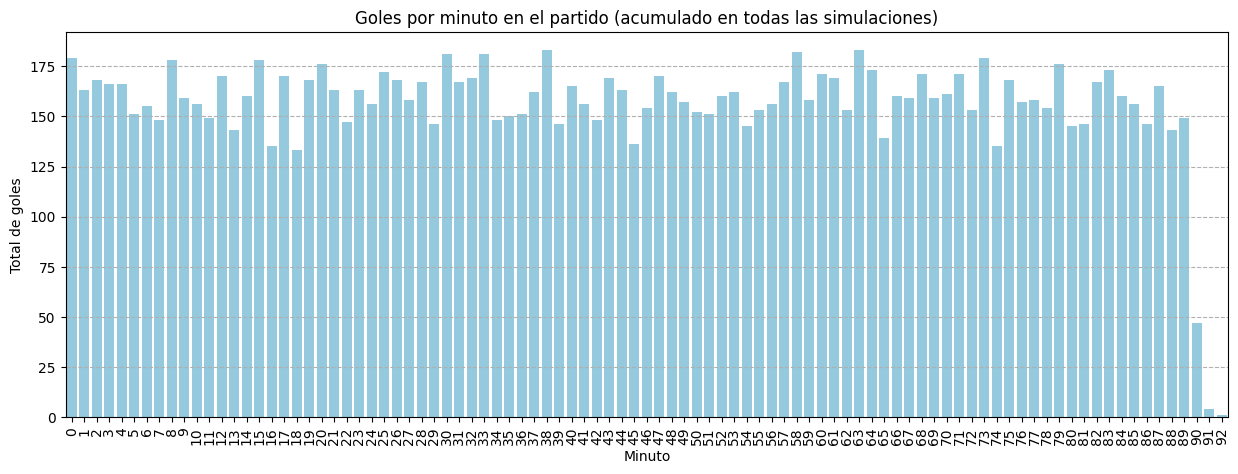

In [111]:
# Grafico de barras para goles por minutos
goals_per_minute = {}
for result in Simulations:
    for i in range(len(result.events_during_match)):
        if "Gol!!!!" not in result.events_during_match[i][0]:
            continue
        if i not in goals_per_minute.keys():
            goals_per_minute[i] = 1
        else:
            goals_per_minute[i] += 1


# Crear gráfica
plt.figure(figsize=(15, 5))
sns.barplot(x=list(goals_per_minute.keys()), y=list(goals_per_minute.values()), color='skyblue')
plt.title("Goles por minuto en el partido (acumulado en todas las simulaciones)")
plt.xlabel("Minuto")
plt.ylabel("Total de goles")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--')
plt.show()